<a href="https://colab.research.google.com/github/bodkhesakshi03-dotcom/Python_Libraries_Assignment_Solutions/blob/main/s_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("insurance (1).csv")

print(df.head(10))


   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86
5   31  female  25.7         0     no  southeast   3756.62
6   46  female  33.4         1     no  southeast   8240.59
7   37  female  27.7         3     no  northwest   7281.51
8   37    male  29.8         2     no  northeast   6406.41
9   60  female  25.8         0     no  northwest  28923.14


In [10]:
print("Shape:", df.shape)

# Info about columns
print("\nInfo:")
print(df.info())

print("\nSummary:")
print(df.describe())


Shape: (1338, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Summary:
               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.000000    34.700

In [11]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [12]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['age', 'bmi', 'children', 'expenses']
Categorical columns: ['sex', 'smoker', 'region']


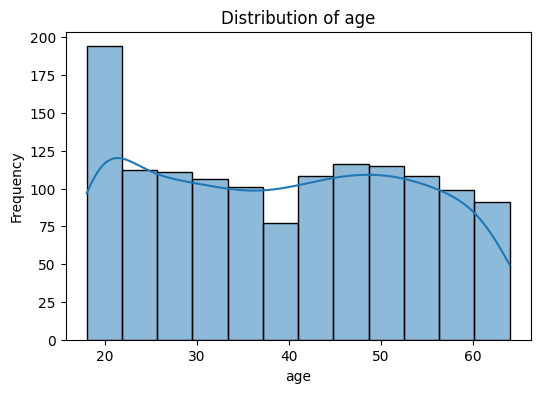

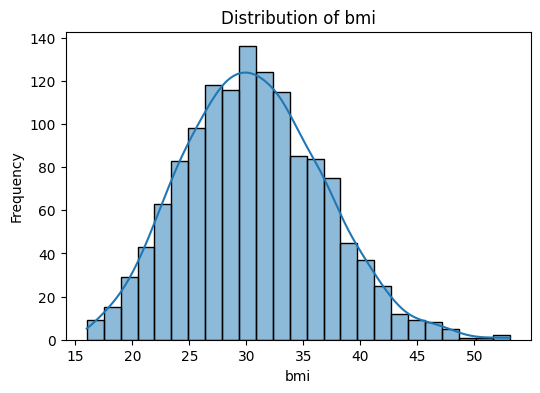

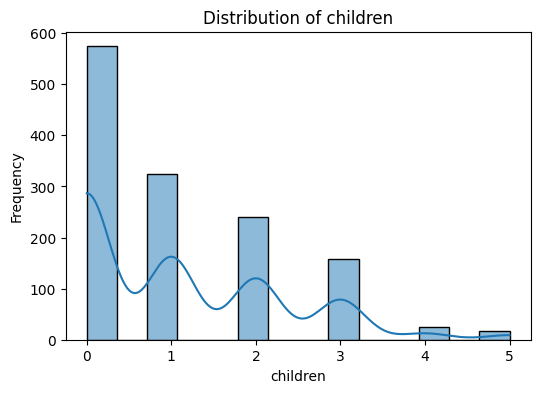

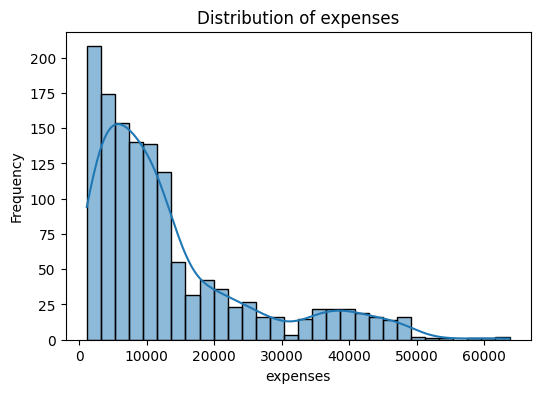

In [13]:
for col in ['age','bmi','children','expenses']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


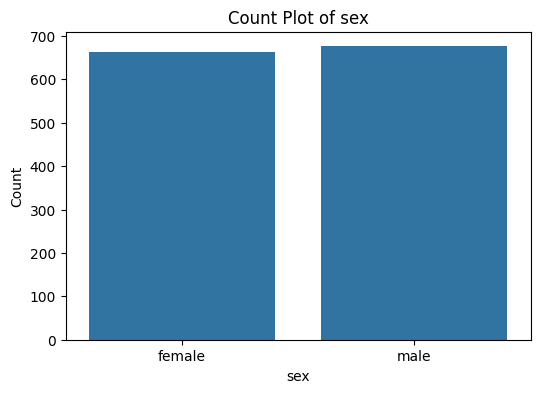

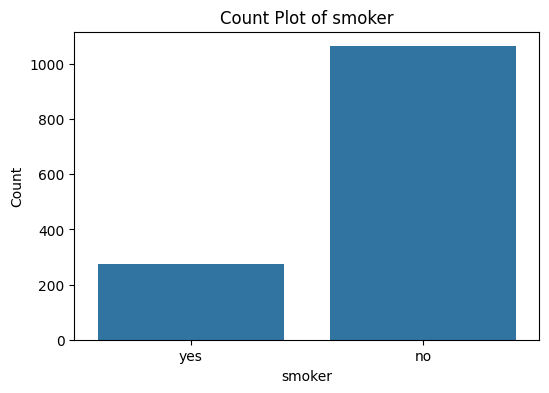

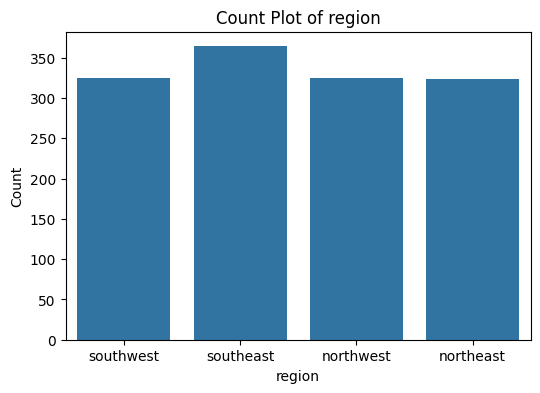

In [14]:
for col in ['sex','smoker','region']:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


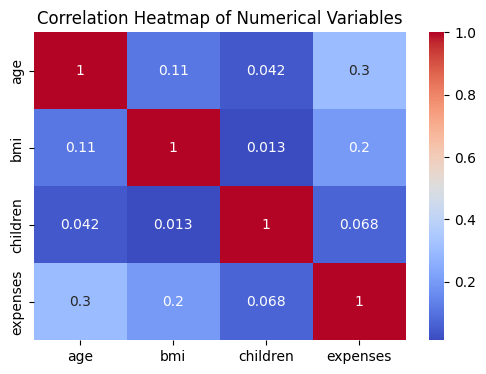

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()



In [17]:
print("Average expenses:", df['expenses'].mean())
print("Max expenses:", df['expenses'].max())
print("Min expenses:", df['expenses'].min())

print("\nAverage expenses by smoker status:")
print(df.groupby('smoker')['expenses'].mean())


Average expenses: 13270.422414050823
Max expenses: 63770.43
Min expenses: 1121.87

Average expenses by smoker status:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


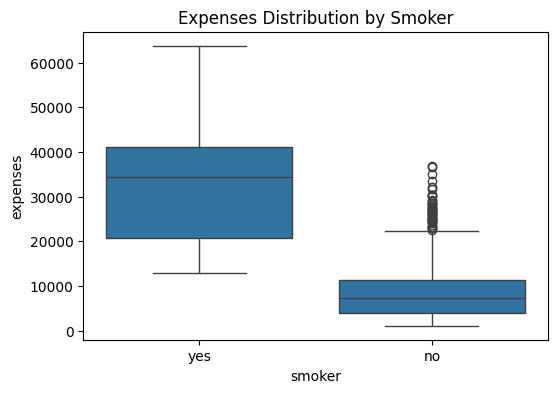

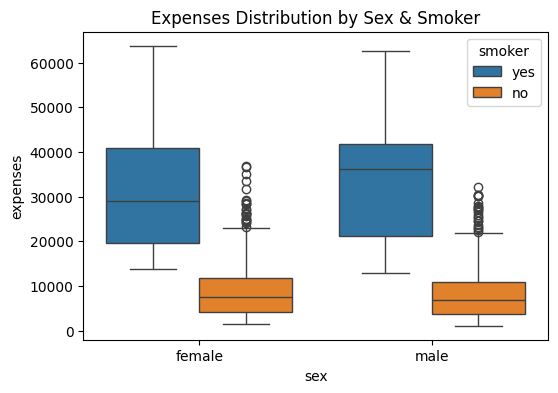

In [18]:
# Expenses vs smoker
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='expenses', data=df)
plt.title("Expenses Distribution by Smoker")
plt.show()

# Expenses vs sex with smoker hue
plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='expenses', hue='smoker', data=df)
plt.title("Expenses Distribution by Sex & Smoker")
plt.show()


In [19]:
avg_age = df['age'].mean()
avg_bmi = df['bmi'].mean()
top_region = df['region'].value_counts().idxmax()

summary = f"""
### Analysis Summary
1. Average Age: {avg_age:.2f}, Average BMI: {avg_bmi:.2f}
2. Smoking strongly increases insurance expenses.
3. Region with highest customers: {top_region}
4. Observations:
   - Smokers have much higher expense outliers.
   - BMI and age distributions show typical health risk spread.
   - Southeast region often shows higher charges.
"""
print(summary)



### Analysis Summary
1. Average Age: 39.21, Average BMI: 30.67
2. Smoking strongly increases insurance expenses.
3. Region with highest customers: southeast
4. Observations:
   - Smokers have much higher expense outliers.
   - BMI and age distributions show typical health risk spread.
   - Southeast region often shows higher charges.



In [26]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [27]:
import pandas as pd
df = pd.read_csv("train.csv")
print(df.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [32]:
print(df.shape)
print(df.info())
print(df.describe())


(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842 

In [33]:
print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [34]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical:", num_cols)
print("Categorical:", cat_cols)


Numerical: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


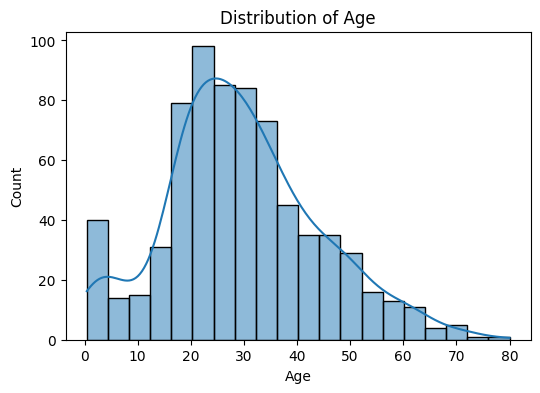

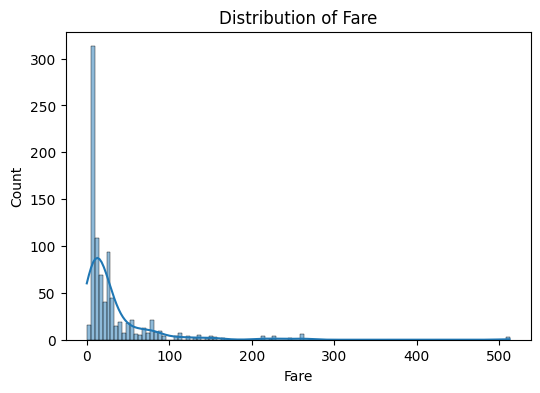

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['Age','Fare']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


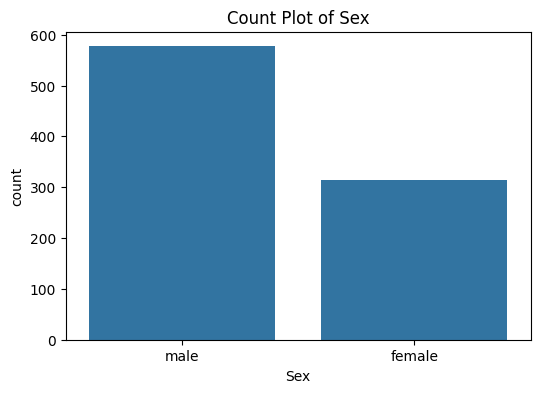

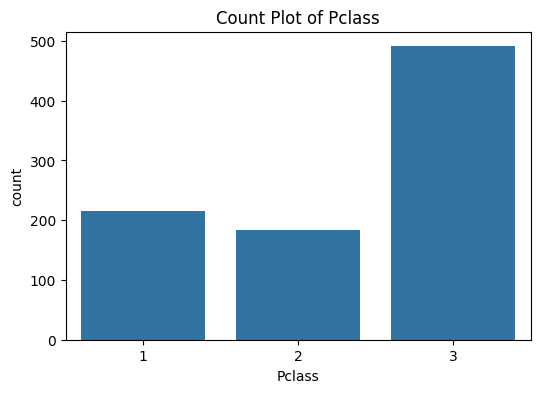

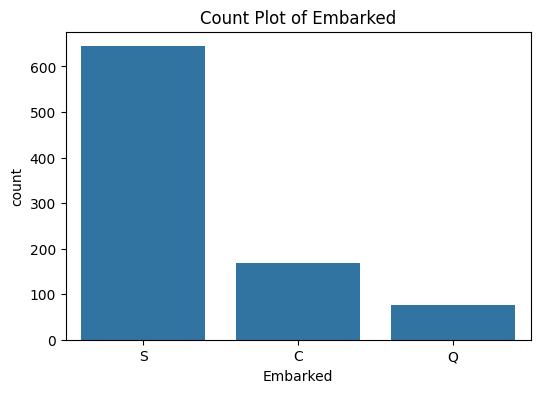

In [36]:
for col in ['Sex','Pclass','Embarked']:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.show()


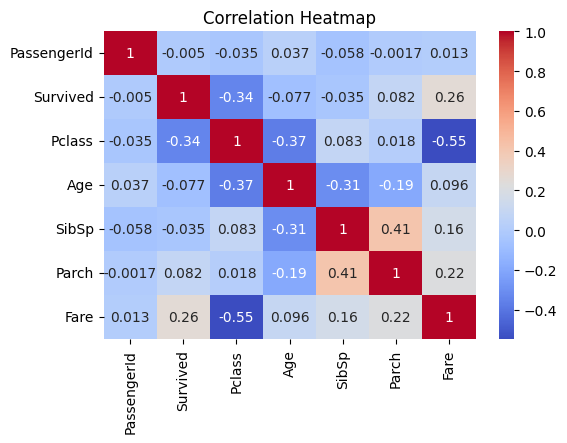

In [37]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [38]:
print("Survival by Sex:\n", df.groupby('Sex')['Survived'].mean())
print("Survival by Pclass:\n", df.groupby('Pclass')['Survived'].mean())


Survival by Sex:
 Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Survival by Pclass:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


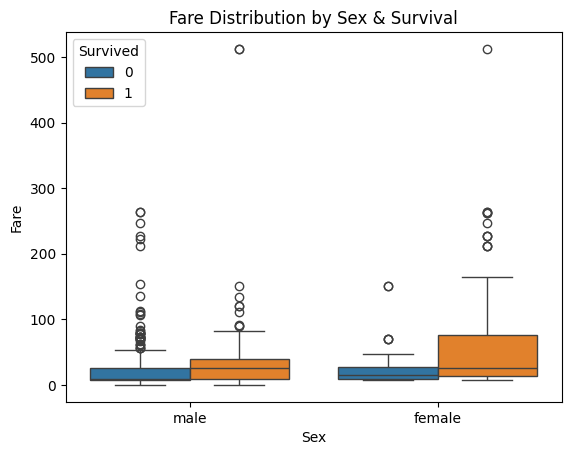

In [39]:
sns.boxplot(x='Sex', y='Fare', hue='Survived', data=df)
plt.title("Fare Distribution by Sex & Survival")
plt.show()


In [40]:
avg_age = df['Age'].mean()
avg_fare = df['Fare'].mean()
top_embarked = df['Embarked'].value_counts().idxmax()

summary = f"""
### Titanic EDA Summary
1. Average Age: {avg_age:.2f}, Average Fare: {avg_fare:.2f}
2. Women had higher survival rates than men.
3. Pclass strongly affected survival chances.
4. Most passengers embarked from: {top_embarked}.
"""
print(summary)



### Titanic EDA Summary
1. Average Age: 29.70, Average Fare: 32.20
2. Women had higher survival rates than men.
3. Pclass strongly affected survival chances.
4. Most passengers embarked from: S.

